#**Projeto - "Auditoria Preditiva em Blockchain: Detecção de anomalias em transação usando ML clássico vs. Deep Learning".**


<div style="text-align: justify;"><p>

**O Problema:** Detectar fraudes ou anomalias simulando dados de transações de uma rede Blockchain. Como dados reais de blockchain podem ser difíceis de rotular, vamos criar um gerador de dados sintéticos robusto.  

**O Experimento:** Treinar um modelo de IA clássico (ex: Random Forest ou Isolation Forest via Scikit-learn) e um modelo de Deep Learning (ex: Autoencoder) para resolver o mesmo problema.  

**O Valor:** Comparar tempo de execução, acurácia, complexidade de implementação e custo computacional entre as duas abordagens.</p>

<div style="text-align: justify;"><p>Design e Planejamento do Projeto</p>

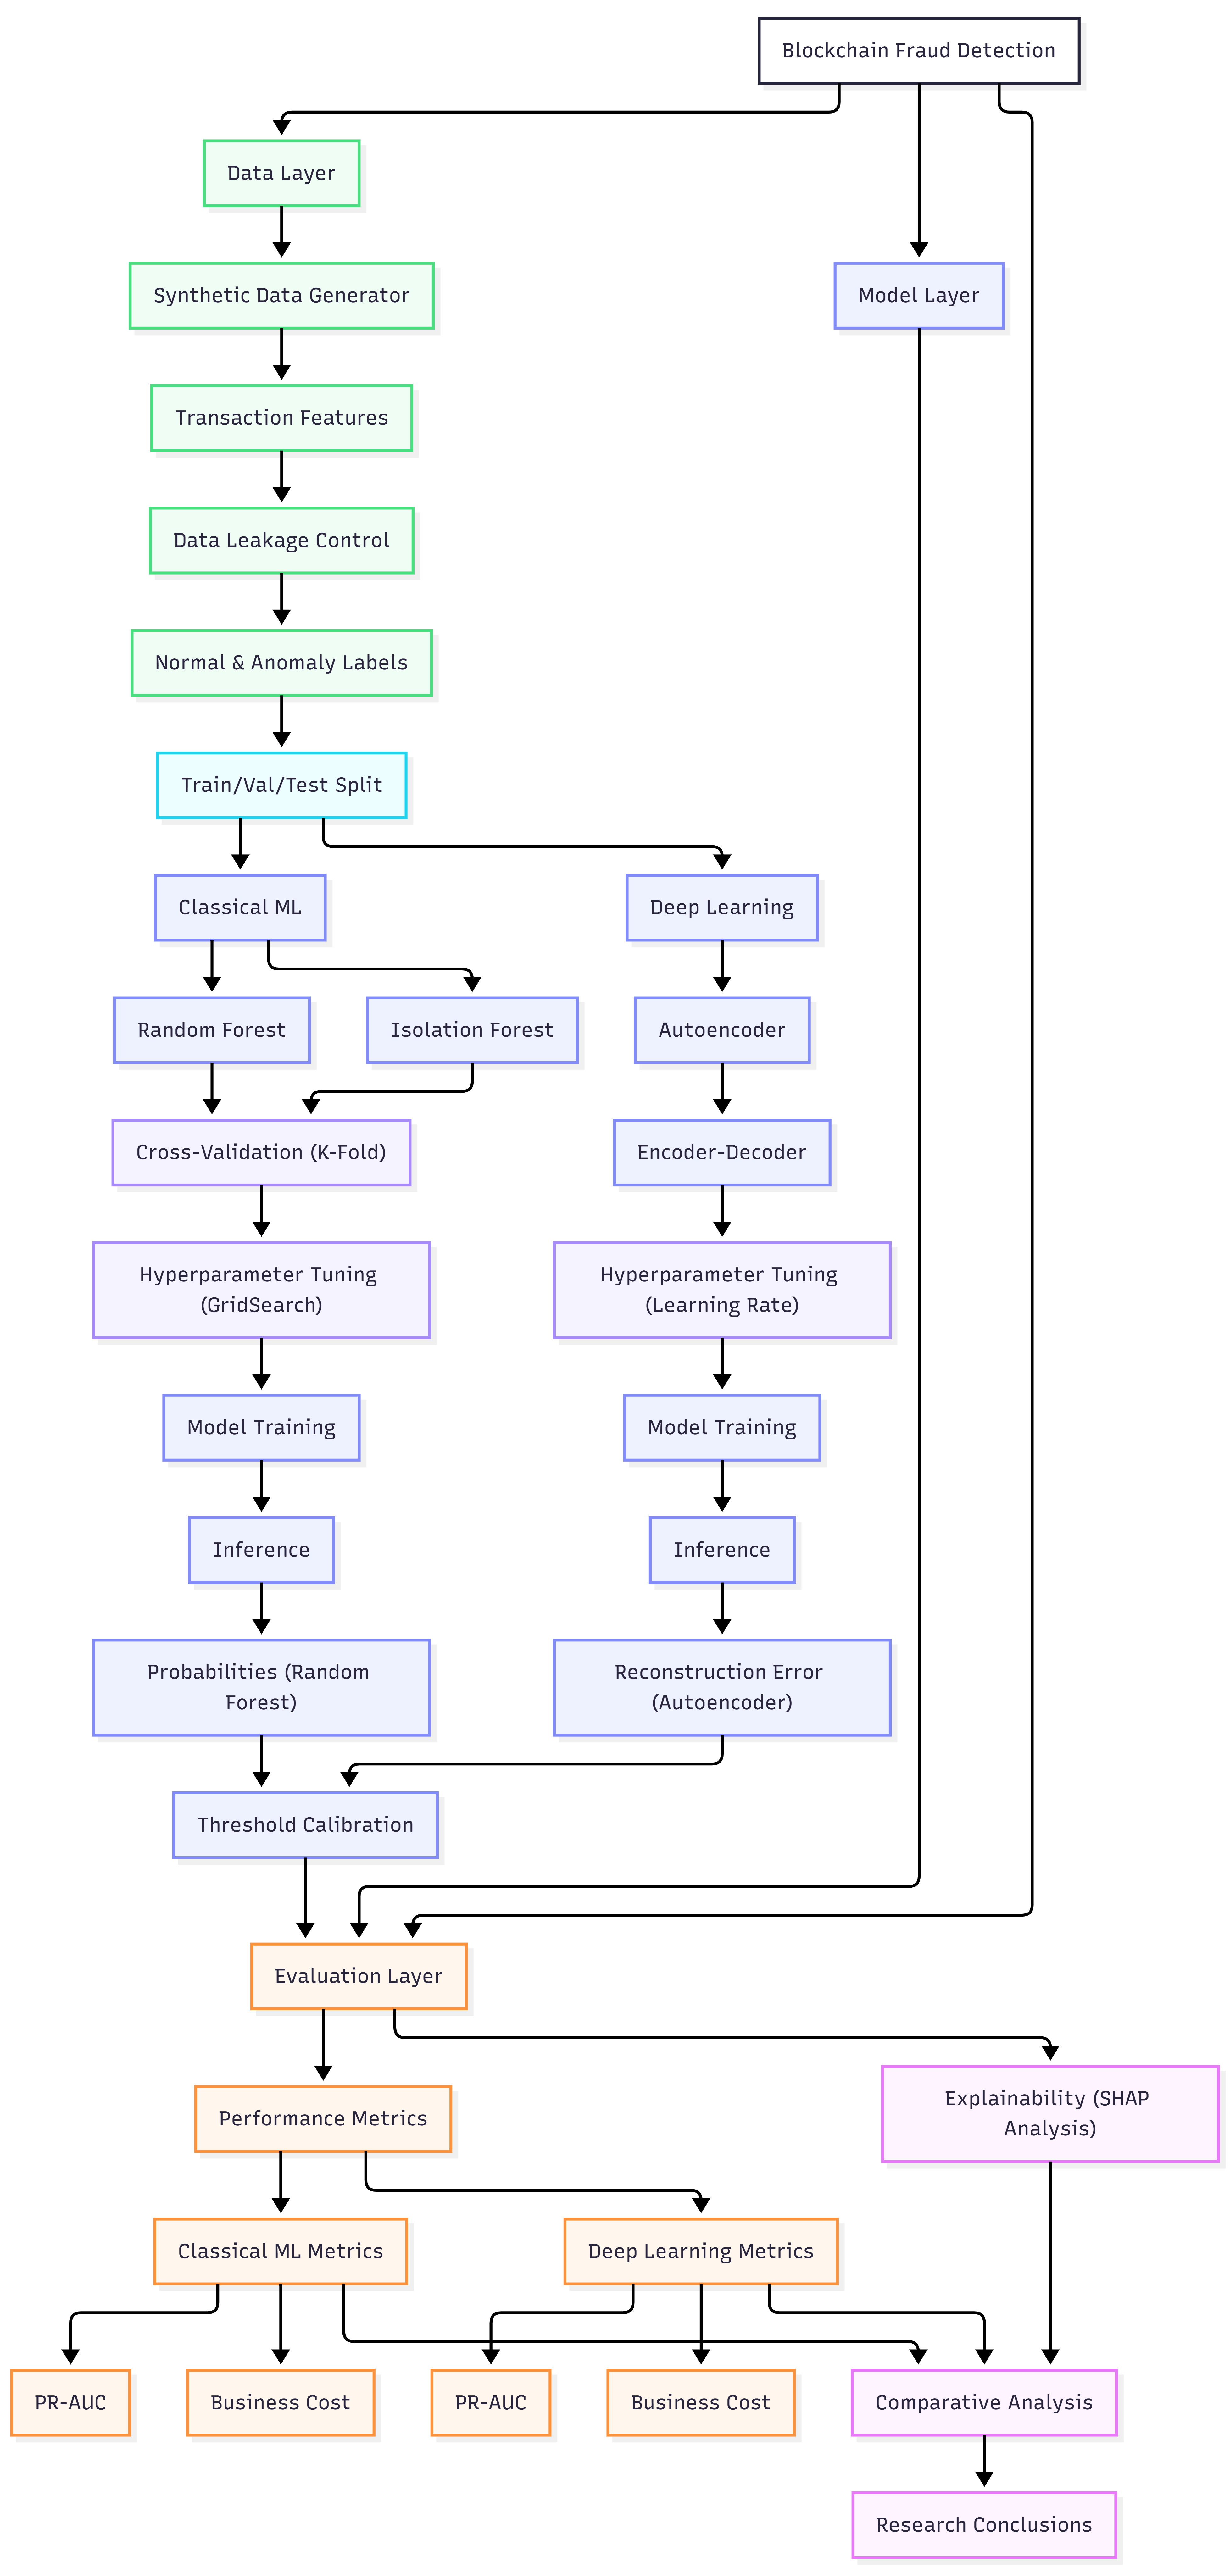

#**Model Layer**

Execução da Data Layer

Construção do pipeline começando pela Data Layer.

O objetivo:

1. Gerar os dados sintéticos (Synthetic Data Generator);
2. Mapear as features do universo Blockchain (Transactions Features);
3. Controlar o vazamento de dados (Data Leakage Control);
4. Fazer o Split temporal (Train/Val/Test Split) .

1: Importação de Bibliotecas

In [1]:
# Célula 1

# Importando as bibliotecas para manipulação estrutural e criação matemática
# do dataset desbalanceado.
# Importando bibliotecas de visualização para validação futura.

!pip install shap -q   # explica os modelos

# Célula 1: Importação das bibliotecas base
import pandas as pd # manipulação estrutural
import numpy as np
from sklearn.datasets import make_classification # criação matemática/desbalanceado
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt  # visualização
import seaborn as sns

# Configuração de estilo para os gráficos futuros
plt.style.use('ggplot')
sns.set_palette("muted")

print("Bibliotecas importadas com sucesso! Ambiente pronto para geração de dados.")

Bibliotecas importadas com sucesso! Ambiente pronto para geração de dados.


2: Geração de Dados Sintéticos e Transaction Features

A fórmula matemática do desbalanceamento pode ser expressa pelo Imbalance Ratio:
$$IR = \frac{N_{majority}}{N_{minority}}$$

O $IR$ é um número que te diz quantas vezes o grupo maior é maior que o grupo menor. A fórmula do IR dita a proporção entre a classe majoritária (Normal) e a minoritária (Fraude).

$$IR = \frac{0.99}{0.01} = 99$$

(99 transações normais para cada 1 fraude).

In [2]:
# Célula 2
# Terá 100.000 transações simuladas. 1% fraudes (anomalias)

# Célula 2: Gerador de Dados Sintéticos Desbalanceados
def generate_blockchain_data(n_samples=100000, fraud_ratio=0.01):
    """
    Gera um dataset sintético imitando transações de Blockchain com forte desbalanceamento.
    """
    # Gerando os dados matemáticos puros
    X, y = make_classification(
        n_samples=n_samples,
        n_features=5,          # 5 features (recursos) relevantes
        n_informative=4,       # 4 features carregam a informação da fraude
        n_redundant=1,         # 1 feature é ruído/redundante
        weights=[1 - fraud_ratio, fraud_ratio], # Desbalanceamento (99% normal, 1% fraude)
        flip_y=0.001,          # Introduz um ruído mínimo (0.1%) nos labels para realismo
        random_state=42        # Garantir reprodutibilidade
    )

    # Mapeando para Features de Negócio (Transaction Features)
    df = pd.DataFrame(X, columns=[
        'Transaction_Value_ETH',
        'Gas_Price_Gwei',
        'Smart_Contract_Calls',
        'Wallet_Age_Days',
        'Time_Between_Tx_Seconds'
    ])

    # Ajustando escalas para parecerem dados reais (ex: idade da carteira não pode ser negativa)
    df['Transaction_Value_ETH'] = np.abs(df['Transaction_Value_ETH']) * 10
    df['Gas_Price_Gwei'] = np.abs(df['Gas_Price_Gwei']) * 50
    df['Smart_Contract_Calls'] = np.abs(np.round(df['Smart_Contract_Calls'] * 2))
    df['Wallet_Age_Days'] = np.abs(df['Wallet_Age_Days']) * 100
    df['Time_Between_Tx_Seconds'] = np.abs(df['Time_Between_Tx_Seconds']) * 60

    df['Is_Fraud'] = y

    return df

# Executando o gerador
blockchain_df = generate_blockchain_data()
print("Dataset de transações Blockchain gerado!")
display(blockchain_df.head())

Dataset de transações Blockchain gerado!


,Transaction_Value_ETH,Gas_Price_Gwei,Smart_Contract_Calls,Wallet_Age_Days,Time_Between_Tx_Seconds,Is_Fraud
0,18.286193,84.391813,5.0,78.701855,107.353155,0
1,22.399444,31.067813,1.0,276.342675,45.180741,0
2,5.254071,5.019163,2.0,42.931475,15.673160,0
3,17.879243,52.859129,7.0,121.524426,33.655572,0
4,7.245603,117.539506,5.0,268.334349,28.690188,0


<div style="text-align: justify;"><p>
Dados do Dataset

1. Valor de transação ETH

2. Preço da gasolina GWEI

3. Chamadas de contrato inteligente

4. Dias de idade para carteiras

5. Tempo entre os segundos de transmissão</P>

3: Controle de Vazamento de Dados e Divisão (Data Leakage Control & Train/Val/Test Split)

Em séries temporais ou dados transacionais, não pode ser feito um split aleatório simples, sob risco de vazar informações do futuro para o passado. Simular a ordenação por tempo resolve isso.

In [3]:
# Célula 3

def split_with_leakage_control(df, target_col='Is_Fraud'):
    """
    Simula o controle de vazamento de dados ordenando por um critério temporal fictício
    antes de realizar a divisão estrita entre Treino, Validação e Teste.
    """
    # 1. Simulação de ordenação temporal (Data Leakage Control)
    df_sorted = df.sort_values(by='Wallet_Age_Days', ascending=True).reset_index(drop=True)

    X = df_sorted.drop(columns=[target_col])
    y = df_sorted[target_col]

    # 2. Train / Temp Split (Mantendo a proporção de fraudes com stratify)
    X_train, X_temp, y_train, y_temp = train_test_split(
        X, y, test_size=0.30, stratify=y, random_state=42 # 70%
    )

    # 3. Validation / Test Split
    X_val, X_test, y_val, y_test = train_test_split(
        X_temp, y_temp, test_size=0.50, stratify=y_temp, random_state=42  # 15%
    )

    return X_train, X_val, X_test, y_train, y_val, y_test

X_train, X_val, X_test, y_train, y_val, y_test = split_with_leakage_control(blockchain_df)

print(f"Tamanho do Treino: {X_train.shape[0]} amostras")
print(f"Tamanho da Validação: {X_val.shape[0]} amostras")
print(f"Tamanho do Teste: {X_test.shape[0]} amostras")

Tamanho do Treino: 70000 amostras
Tamanho da Validação: 15000 amostras
Tamanho do Teste: 15000 amostras


<div style="text-align: justify;"><p>
Acima mostra a distribuição dos dados para:

1. Treino 70% - O Random Forest aprenderá as regras de negócio aqui, e o Autoencoder usará esses dados para aprender qual é o padrão "normal" de uma transação na rede Blockchain.


2. Validação 15% - Durante o treinamento do Autoencoder (Deep Learning), o modelo tentará prever esses dados repetidas vezes para ajustar o Learning Rate (taxa de aprendizado) e parar o treinamento antes que ele decore os dados (técnica de Early Stopping). Nos modelos clássicos, os ajustes dos hiperparâmetros são feitos aqui.

3. Teste 15% - Esses dados são a "prova final" e o modelo não tem contato nenhum com eles durante o treinamento ou validação. Eles são usados apenas uma vez, no final do projeto, para extrairmos as métricas de PR-AUC e Custo de Negócio, garantindo que o modelo funcionará no mundo real com fraudes inéditas.</P>



#**Classical ML**



4: Treinamento e Ajuste de Hiperparâmetros (Random Forest)

<div style="text-align: justify;"><p>Vai ser usado o GridSearchCV para testar várias combinações de árvores. O detalhe é o parâmetro scoring: não usaremos Accuracy, usaremos average_precision (que é a área sob a curva Precision-Recall, ou PR-AUC), garantindo que o modelo foque na minoria (fraudes).

####**Explicando o motivo da troca do parâmetro de pontuação "accuracy" para a métrica "average_precision".**

Quando lidamos com detecção de fraudes, estamos lidando com um problema de desbalanceamento extremo de classes.

Se usar a Acurácia (accuracy) como métrica para o GridSearchCV, o algoritmo tentará maximizar o número total de acertos. O problema é que um modelo "preguiçoso" que simplesmente classifique todas as transações como "Não Fraude" vai acertar 99% das vezes.

Para a métrica de Acurácia, esse é um modelo excelente (99% de acerto). Para o negócio, é um desastre, pois ele deixou passar 100% das fraudes. A Acurácia é cega para a minoria.

------------------------------------------------------------------------

O Random Forest é um algoritmo poderoso e versátil, mas ele tem vários hiperparâmetros que afetam seu comportamento (como n_estimators, max_depth, min_samples_split).

O GridSearchCV testa exaustivamente várias combinações desses parâmetros usando validação cruzada para encontrar a "receita perfeita". No entanto, o GridSearch precisa de uma "bússola" (o parâmetro scoring) para saber qual combinação de hiperparâmetros é a vencedora.

Se a bússola for a Acurácia, o GridSearch vai selecionar a árvore de decisão que melhor ignora as fraudes.

---------------------------------------------------------------------------

Ao alterar o scoring para average_precision, você muda completamente a bússola do GridSearch. Em vez de olhar para o todo, ele passa a focar exclusivamente na qualidade das previsões da classe minoritária (fraudes).

O average_precision calcula a área sob a curva Precision-Recall (PR-AUC). Para entender por que isso é tão poderoso, precisamos olhar para os dois pilares dessa métrica:

Precision (Precisão): De todas as transações que o modelo disse que eram fraude, quantas realmente eram fraude? (Mede a taxa de "alarmes falsos").

Recall (Revocação): De todas as fraudes reais que aconteceram no mundo real, quantas o modelo conseguiu capturar? (Mede a taxa de "pontos cegos").

-------------------------------------------------------------------------

Por que a curva PR-AUC é superior à ROC-AUC?
Em problemas normais, muitos usam a curva ROC-AUC. Porém, a curva ROC usa a taxa de Falsos Positivos, que é dividida pelo total de transações legítimas. Como o número de transações legítimas é gigantesco, a taxa de Falsos Positivos é "diluída" e parece pequena, fazendo o modelo parecer melhor do que é.

A PR-AUC ignora os Verdadeiros Negativos (as transações legítimas corretas). Ela avalia o modelo estritamente pela sua capacidade de acertar as fraudes (Recall) sem bloquear muitos clientes bons no processo (Precision).

**O Resultado**

Quando roda o GridSearchCV(estimator=rf, param_grid=parametros, scoring='average_precision'), o fluxo funciona assim:

O modelo treina uma combinação de hiperparâmetros da Random Forest.

Ele avalia o resultado olhando estritamente para o equilíbrio entre capturar fraudes e evitar falsos bloqueios.

Ele descarta modelos que têm alta acurácia mas deixam fraudes passar.

Resultado final: O GridSearch devolve os hiperparâmetros que geram a Random Forest mais letal possível contra os fraudadores.</p>


In [4]:
# Célula 4

from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import StratifiedKFold, GridSearchCV
from sklearn.metrics import average_precision_score
import time

print("Iniciando o treinamento do Random Forest com GridSearchCV...")
start_time = time.time()

# 1. Definindo o modelo base com peso balanceado para lidar com o desbalanceamento
rf_base = RandomForestClassifier(class_weight='balanced', random_state=42)

# 2. Espaço de busca de hiperparâmetros (Hyperparameter Tuning)
# Mantemos simples para rodar rápido no MVP
param_grid = {
    'n_estimators': [50, 100],
    'max_depth': [5, 10, None],
    'min_samples_split': [2, 5]
}

# 3. Validação Cruzada Estratificada (Cross-Validation K-Fold)
# Garante que todas as 5 dobras tenham a mesma proporção de fraudes
cv_strategy = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

# 4. Grid Search focando em PR-AUC (average_precision)
grid_search = GridSearchCV(
    estimator=rf_base,
    param_grid=param_grid,
    cv=cv_strategy,
    scoring='average_precision',
    n_jobs=-1, # Usa todos os núcleos do processador
    verbose=1
)

# Treinando apenas com os dados de TREINO
grid_search.fit(X_train, y_train)
rf_best_model = grid_search.best_estimator_

rf_train_time = time.time() - start_time
print(f"Treinamento concluído em {rf_train_time:.2f} segundos.")
print(f"Melhores hiperparâmetros: {grid_search.best_params_}")

Iniciando o treinamento do Random Forest com GridSearchCV...
Fitting 5 folds for each of 12 candidates, totalling 60 fits
Treinamento concluído em 456.13 segundos.
Melhores hiperparâmetros: {'max_depth': None, 'min_samples_split': 5, 'n_estimators': 100}


5: Calibração do Limiar de Detecção (Threshold Calibration)

Modelos clássicos geralmente classificam algo como fraude se a probabilidade for maior que 50% (0.5). Em bases com 1% de fraude, isso é um erro fatal. O modelo pode prever 40% de chance de fraude para uma transação altamente suspeita e, pelo limite padrão de 0.5, deixá-la passar como "normal".

Será usado dados de Validação para encontrar o melhor ponto de corte (threshold) que maximize o equilíbrio entre Precision e Recall (usando o F1-Score).

Calibrando o limiar (Threshold) usando os dados de Validação...
Limiar Padrão (0.5) - ignorado.
Limiar Calibrado Ideal: 0.1985 (F1-Score: 0.4516)


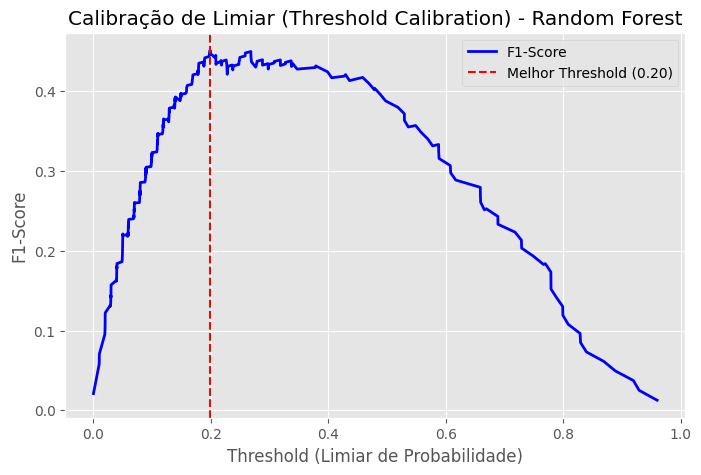

In [5]:
# Célula 5
from sklearn.metrics import precision_recall_curve, f1_score

print("Calibrando o limiar (Threshold) usando os dados de Validação...")

# 1. Obter as probabilidades previstas para a classe positiva (Fraude) no conjunto de VALIDAÇÃO
y_val_probs = rf_best_model.predict_proba(X_val)[:, 1]

# 2. Calcular Precision, Recall e os limiares (thresholds)
precisions, recalls, thresholds = precision_recall_curve(y_val, y_val_probs)

# 3. Calcular o F1-Score para cada threshold (evitando divisão por zero)
f1_scores = 2 * (precisions * recalls) / (precisions + recalls + 1e-10)

# 4. Encontrar o índice do maior F1-Score
best_idx = np.argmax(f1_scores)
best_threshold_rf = thresholds[best_idx]
best_f1_rf = f1_scores[best_idx]

print(f"Limiar Padrão (0.5) - ignorado.")
print(f"Limiar Calibrado Ideal: {best_threshold_rf:.4f} (F1-Score: {best_f1_rf:.4f})")

# Visualização da calibração
plt.figure(figsize=(8, 5))
plt.plot(thresholds, f1_scores[:-1], "b-", label="F1-Score", linewidth=2)
plt.axvline(x=best_threshold_rf, color='r', linestyle='--', label=f'Melhor Threshold ({best_threshold_rf:.2f})')
plt.title("Calibração de Limiar (Threshold Calibration) - Random Forest")
plt.xlabel("Threshold (Limiar de Probabilidade)")
plt.ylabel("F1-Score")
plt.legend()
plt.show()

<div style="text-align: justify;"><p>

O Random Forest está otimizado e calibrado, que reflete exatamente como sistemas antifraude funcionam em produção.

Esse gráfico é a visualização da Calibração do Limiar (Threshold). Ele mostra visualmente como encontrar o "ponto de equilíbrio perfeito" para o seu modelo tomar decisões.

* Eixo X (Threshold / Limiar de Probabilidade): Vai de 0.0 a 1.0. É o "nível de exigência" do modelo. O modelo Random Forest não diz simplesmente "é fraude" ou "não é". Ele cospe uma probabilidade (ex: "tem 30% de chance de ser fraude"). O threshold é a nota de corte. Se o threshold for 0.30, qualquer transação com 30% ou mais de risco será bloqueada.

* Eixo Y (F1-Score): É a nota que mede o equilíbrio perfeito entre Precision (não bloquear clientes bons) e Recall (capturar o máximo de fraudes). Quanto mais alto, melhor o modelo está balanceando esses dois mundos.

* A linha azul tem o formato de uma montanha. Ela conta uma história sobre o que acontece quando move-se a "nota de corte" (threshold):

* Lado Esquerdo (Thresholds baixos, ex: 0.10): Se bloquear qualquer transação que tenha apenas 10% de chance de ser fraude, vai capturar todas as fraudes (Recall alto). Mas vai bloquear milhares de clientes legítimos (Precision péssima). Por causa desse excesso de alarmes falsos, o F1-Score é baixo.

* Lado Direito (Thresholds altos, ex: 0.90): Se for conservador e só bloquear quando tiver 90% de certeza, não vai incomodar nenhum cliente bom (Precision alta). Porém, dezenas de fraudadores astutos vão passar despercebidos (Recall péssimo). O F1-Score cai drasticamente.

* O Topo da Montanha: É o ponto onde a linha azul atinge a altura máxima. Esse é o limite ótimo matemático onde captura o máximo possível de fraudes estressando o mínimo possível de clientes bons.

É aqui que entra a genialidade do código.

* Por padrão, a biblioteca scikit-learn usa um threshold cego de 0.50 (50%). Mas em problemas de fraude, exigir 50% de certeza pode ser alto demais e deixar fraudes passarem.

* O código vasculhou todos os thresholds possíveis, calculou a nota (F1-Score) de cada um e encontrou o índice do vencedor (best_idx = np.argmax(f1_scores)).

* A linha vermelha tracejada marca exatamente onde esse vencedor está no eixo X. Se a linha vermelha cair em 0.28, por exemplo, o gráfico está dizendo: "Esqueça a regra padrão de 0.50. Para o seu negócio, comece a bloquear as transações assim que o modelo der 28% de probabilidade de ser fraude. Esse é o seu limite ideal."

* Resumo da Ópera: O gráfico prova que aceitar o padrão de fábrica (0.50) é um erro em cenários de fraude. Ele desenha a justificativa exata de escolher um threshold customizado para colocar em produção.</p>



#**Deep Learning**

<div style="text-align: justify;"><p>

De acordo com o fluxo do diagrama o correto em uma pesquisa comparativa é ter os dois "competidores" treinados, calibrados e aguardando na linha de largada. Depois, soltar os dados de Teste (X_test) para ambos simultaneamente e comparar os resultados lado a lado.</p>

6: Pré-processamento e Construção do Autoencoder

<div style="text-align: justify;"><p>

Redes neurais são extremamente sensíveis à escala dos dados (diferente do Random Forest, que ignora isso). O primeiro passo aqui é normalizar os dados e, em seguida, treinar o Autoencoder (Auto-codificador) apenas com os dados normais, pois a lógica dele é aprender o padrão do que é "comum".

Os Autoencoder é uma arquitetura de rede neural de compactação.
Redes neurais são extremamente sensíveis à escala dos dados (diferente do Random Forest, que ignora isso). O primeiro passo aqui é normalizar os dados e, em seguida, treinar o Autoencoder (Auto-codificador) apenas com os dados normais, pois a lógica dele é aprender o padrão do que é "comum". É uma técnica de aprendizagem não supervisionada (não precisa de rótulos) cujo objetivo é comprimir os dados em uma representação menor e, em seguida, tentar reconstruí-los o mais fielmente possível.</p>

In [6]:
# Célula 6
from sklearn.preprocessing import StandardScaler
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Input, Dense
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping

print("Preparando dados e construindo o Autoencoder...")

# 1. Padronização (Scaling) - CRÍTICO para Deep Learning
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_val_scaled = scaler.transform(X_val)
X_test_scaled = scaler.transform(X_test) # Já deixamos pronto para o final

# 2. Filtrando apenas transações normais para treinar o Autoencoder
# O modelo deve aprender a reconstruir apenas o que é "normal"
X_train_normal = X_train_scaled[y_train == 0]
X_val_normal = X_val_scaled[y_val == 0]

# 3. Arquitetura do Autoencoder (Encoder-Decoder)
input_dim = X_train.shape[1]
input_layer = Input(shape=(input_dim,))

# Encoder (Comprimindo a informação)
encoder = Dense(8, activation="relu")(input_layer)
encoder = Dense(4, activation="relu")(encoder) # Gargalo (Bottleneck)

# Decoder (Reconstruindo a informação)
decoder = Dense(8, activation="relu")(encoder)
output_layer = Dense(input_dim, activation="linear")(decoder)

autoencoder = Model(inputs=input_layer, outputs=output_layer)

# Hyperparameter Tuning: Ajustando o Learning Rate
optimizer = Adam(learning_rate=0.001)
autoencoder.compile(optimizer=optimizer, loss="mse")

# Early Stopping para evitar Overfitting
early_stopping = EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True)

print("Treinando a Rede Neural...")
# 4. Model Training
history = autoencoder.fit(
    X_train_normal, X_train_normal, # Entrada e saída são iguais (reconstrução)
    epochs=50,
    batch_size=32,
    validation_data=(X_val_normal, X_val_normal),
    callbacks=[early_stopping],
    verbose=1
)
print("Treinamento do Autoencoder concluído.")

Preparando dados e construindo o Autoencoder...
Treinando a Rede Neural...
Epoch 1/50
2165/2165 ━━━━━━━━━━━━━━━━━━━━ 6s 2ms/step - loss: 0.2447 - val_loss: 0.0297
Epoch 2/50
2165/2165 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step - loss: 0.0257 - val_loss: 0.0236
Epoch 3/50
2165/2165 ━━━━━━━━━━━━━━━━━━━━ 6s 3ms/step - loss: 0.0241 - val_loss: 0.0231
Epoch 4/50
2165/2165 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step - loss: 0.0239 - val_loss: 0.0232
Epoch 5/50
2165/2165 ━━━━━━━━━━━━━━━━━━━━ 5s 2ms/step - loss: 0.0237 - val_loss: 0.0232
Epoch 6/50
2165/2165 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - loss: 0.0236 - val_loss: 0.0229
Epoch 7/50
2165/2165 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step - loss: 0.0235 - val_loss: 0.0226
Epoch 8/50
2165/2165 ━━━━━━━━━━━━━━━━━━━━ 7s 3ms/step - loss: 0.0233 - val_loss: 0.0225
Epoch 9/50
2165/2165 ━━━━━━━━━━━━━━━━━━━━ 5s 2ms/step - loss: 0.0232 - val_loss: 0.0224
Epoch 10/50
2165/2165 ━━━━━━━━━━━━━━━━━━━━ 6s 2ms/step - loss: 0.0230 - val_loss: 0.0224
Epoch 11/50
2165/2165 ━━━━━━━━━━━━━━━━━━━━ 5

Acima representa o coração do sistema de detecção de anomalias por Deep Learning.
Prepara os dados, monta a arquitetura do modelo e executa o treinamento.

7: Inferência e Calibração do Limiar (Reconstruction Error)

Ao contrário do Random Forest, que cospe uma "probabilidade", o Autoencoder cospe um Erro de Reconstrução (MSE). Se o erro for baixo, a transação é normal (ele já viu algo parecido). Se o erro for muito alto, é uma anomalia (fraude inédita). Precisamos calibrar qual é o valor exato desse erro que define o corte.

Calibrando o limiar de anomalia do Autoencoder...
469/469 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step
Limiar (Erro de Reconstrução) Calibrado Ideal: 0.2177 (F1-Score: 0.2878)


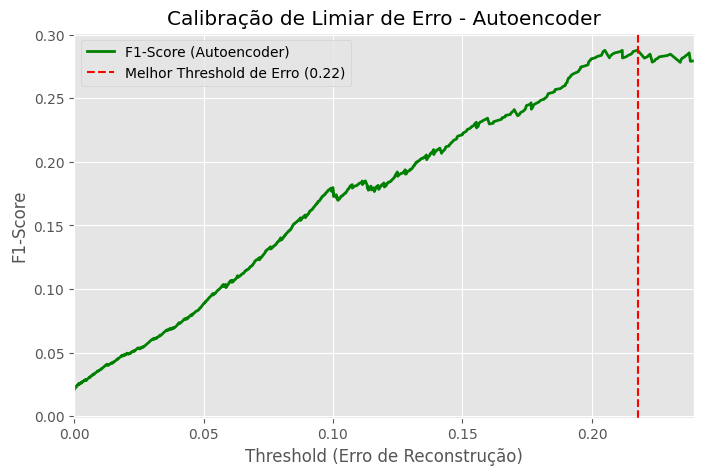

In [9]:
# Célula 7
from sklearn.metrics import mean_squared_error, precision_recall_curve
import numpy as np
import matplotlib.pyplot as plt

print("Calibrando o limiar de anomalia do Autoencoder...")

# 1. Inferência: Tentar reconstruir TODOS os dados de Validação
X_val_predictions = autoencoder.predict(X_val_scaled)

# 2. Calcular o erro de reconstrução (MSE)
mse_val = np.mean(np.power(X_val_scaled - X_val_predictions, 2), axis=1)

# 3. Calibração usando F1-Score
precisions_ae, recalls_ae, thresholds_ae = precision_recall_curve(y_val, mse_val)

# Calculando F1-Score
f1_scores_ae = 2 * (precisions_ae * recalls_ae) / (precisions_ae + recalls_ae + 1e-10)
best_idx_ae = np.argmax(f1_scores_ae)

best_threshold_ae = thresholds_ae[best_idx_ae]
best_f1_ae = f1_scores_ae[best_idx_ae]

print(f"Limiar (Erro de Reconstrução) Calibrado Ideal: {best_threshold_ae:.4f} (F1-Score: {best_f1_ae:.4f})")

# Visualização da calibração do Autoencoder
plt.figure(figsize=(8, 5))
plt.plot(thresholds_ae, f1_scores_ae[:-1], "g-", label="F1-Score (Autoencoder)", linewidth=2)
plt.axvline(x=best_threshold_ae, color='r', linestyle='--', label=f'Melhor Threshold de Erro ({best_threshold_ae:.2f})')
plt.title("Calibração de Limiar de Erro - Autoencoder")
plt.xlabel("Threshold (Erro de Reconstrução)")
plt.ylabel("F1-Score")

# CORREÇÃO AQUI: Garante que o limite do eixo X sempre mostre o threshold ideal com uma margem de 10%
limite_percentil = np.percentile(mse_val, 99)
limite_x = max(limite_percentil, best_threshold_ae * 1.1)
plt.xlim(0, limite_x)

plt.legend()
plt.show()

É aqui que descobre se a teoria de "aprender o normal para rejeitar o anormal" funcionou na prática, e define a partir de qual ponto o sistema deve disparar o alarme de fraude.

* Inferência (O Teste): O comando autoencoder.predict(X_val_scaled) passa os dados de validação pelo modelo. Detalhe importante: dessa vez, a base de validação tem tanto transações normais quanto fraudes. O modelo vai tentar reconstruir todas elas.

* Cálculo do Erro (MSE): A linha mse_val = ... calcula a diferença entre a transação original e a tentativa de reconstrução do modelo. Ela usa o Erro Quadrático Médio (MSE).

* Se a transação for normal, o modelo saberá reconstruir e o erro será baixo.

* Se a transação for fraude, o modelo ficará confuso (pois nunca viu isso no treino) e a reconstrução ficará péssima. O erro será alto.

* Calibração: Assim como foi feito no Random Forest, o código testa vários limites (thresholds). Só que, em vez de probabilidade (0% a 100%), ele está testando valores de Erro de Reconstrução. Ele calcula o F1-Score para cada nível de erro possível e escolhe aquele que melhor equilibra a captura de fraudes com a aprovação de clientes legítimos.

* O gráfico mostra visualmente a busca pelo limite de tolerância a erros do seu modelo. Ele responde à pergunta: "Quão alto o erro de reconstrução precisa ser para termos certeza de que é uma fraude e não apenas uma transação normal um pouco diferente?"

* Eixo X (Threshold / Erro de Reconstrução): Representa o tamanho do erro que o modelo cometeu ao tentar reconstruir a transação. Quanto mais para a direita, mais desfigurada ficou a reconstrução (maior o erro).

* Eixo Y (F1-Score): Representa a qualidade da decisão. Quanto mais alto, melhor o equilíbrio entre pegar fraudadores (Recall) e não irritar clientes bons (Precision).

* A Linha Verde: Mostra a evolução da sua nota (F1-Score) conforme você aumenta a exigência. Se você colocar um limite de erro muito baixo (esquerda), qualquer errinho o modelo diz que é fraude (muito alarme falso). Se colocar muito alto (direita), só as fraudes mais absurdas são pegas.

* A Linha Vermelha Tracejada: É o Limiar Calibrado Ideal. É o pico da montanha verde. Ela marca exatamente o valor do Erro de Reconstrução (ex: 0.15, 0.40, etc.) que você deve usar em produção.

* Qualquer transação nova cujo erro de reconstrução ultrapassar o valor da linha vermelha será automaticamente bloqueada e classificada como anomalia/fraude pelo seu sistema.

**Finalizado o Model Layer**

Os dois modelos estão altamente tunados e com seus limiares de decisão otimizados para o problema de négocios.

#**Evaluation Layer**

Os erros dos modelos serão traduzidos em dinheiro (Custo de Negócio)

8: Avaliação Final e Cálculo do Custo de Negócio

No mundo real de prevenção a fraudes, os erros têm pesos diferentes.
A equação de custo que utilizaremos é:

$$Custo_{Total} = (FP \times C_{FP}) + (FN \times C_{FN})$$

Falso Positivo (FP): Bloquear uma transação legítima. Causa atrito com o cliente. Custo estimado: US$ 10.


Falso Negativo (FN): Deixar uma fraude passar. A empresa assume o prejuízo. Custo estimado: US$ 1.000.

In [10]:
# Célula 8
from sklearn.metrics import confusion_matrix, average_precision_score

print("Avaliando modelos nos dados de Teste...")

# 1. Avaliação do Random Forest (ML Clássico)
y_test_probs = rf_best_model.predict_proba(X_test)[:, 1]
# Aplicando o threshold calibrado que encontramos no Passo 5
y_test_pred_rf = (y_test_probs >= best_threshold_rf).astype(int)

# 2. Avaliação do Autoencoder (Deep Learning)
X_test_predictions = autoencoder.predict(X_test_scaled)
mse_test = np.mean(np.power(X_test_scaled - X_test_predictions, 2), axis=1)
# Aplicando o threshold de erro calibrado que encontramos no Passo 7
y_test_pred_ae = (mse_test >= best_threshold_ae).astype(int)

# 3. Função para calcular o Custo de Negócio
def calculate_business_cost(y_true, y_pred, cost_fp=10, cost_fn=1000):
    tn, fp, fn, tp = confusion_matrix(y_true, y_pred).ravel()
    total_cost = (fp * cost_fp) + (fn * cost_fn)
    return total_cost, fp, fn

# 4. Extraindo as métricas finais
cost_rf, fp_rf, fn_rf = calculate_business_cost(y_test, y_test_pred_rf)
pr_auc_rf = average_precision_score(y_test, y_test_probs)

cost_ae, fp_ae, fn_ae = calculate_business_cost(y_test, y_test_pred_ae)
# Para o PR-AUC do Autoencoder, usamos o MSE como "probabilidade" de ser anomalia
pr_auc_ae = average_precision_score(y_test, mse_test)

print("\n--- RESULTADOS FINAIS DE NEGÓCIO ---")
print(f"RANDOM FOREST: PR-AUC = {pr_auc_rf:.4f} | Custo Financeiro Estimado: US$ {cost_rf}")
print(f"AUTOENCODER  : PR-AUC = {pr_auc_ae:.4f} | Custo Financeiro Estimado: US$ {cost_ae}")

Avaliando modelos nos dados de Teste...
469/469 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step

--- RESULTADOS FINAIS DE NEGÓCIO ---
RANDOM FOREST: PR-AUC = 0.4332 | Custo Financeiro Estimado: US$ 89830
AUTOENCODER  : PR-AUC = 0.2343 | Custo Financeiro Estimado: US$ 116860


Aplicando a Nota de Corte na Prática

O código acima pega os modelos e joga contra a base de teste (X_test), simulando transações reais chegando ao sistema.

No Random Forest (Passo 1): Ele gera as probabilidades de fraude e aplica a "nota de corte" (best_threshold_rf) que foi calibrada na Célula 5. Se a probabilidade bater no limiar, o modelo "carimba" como fraude (1).

No Autoencoder (Passo 2): Ele tenta reconstruir as transações, calcula o erro de cada uma (MSE) e aplica o limiar de erro (best_threshold_ae) da Célula 7. Se o erro for maior que o permitido, ele "carimba" como anomalia/fraude (1).

------------------------------------------------------------------------

A Função de Custo de Negócio (A Visão do Diretor)

A função calculate_business_cost faz exatamente isso usando a Matriz de Confusão para extrair dois erros vitais:

Falso Positivo (fp): Você bloqueou um cliente legítimo. O código arbitrou que isso custa US$ 10 (custo do atendimento no call center, atrito, perda da taxa de transação).

Falso Negativo (fn): Você deixou um fraudador passar. O código arbitrou que isso custa US$ 1000 (valor do chargeback, produto roubado, multa da bandeira do cartão).

O Custo Total do modelo é a soma do prejuízo gerado pelos Falsos Positivos e Falsos Negativos. O melhor modelo é aquele que tiver o menor custo financeiro.

Extraindo Métricas e o Resumo Final
Por fim, o código calcula as notas finais para colocar lado a lado:

PR-AUC: É a métrica técnica que mostra a qualidade bruta do modelo em lidar com dados desbalanceados (quanto mais perto de 1.0, melhor). Para o Autoencoder, ele usa inteligentemente o erro (MSE) no lugar da probabilidade, já que quanto maior o erro, maior a "probabilidade" de ser anomalia.

Custo Financeiro Estimado: O valor em dólares que cada modelo causaria de prejuízo operacional se estivesse no ar durante aquele lote de transações.

9: Análise Comparativa Visual (Matriz de Confusão)

Para apresentar aos stakeholders é gerado os gráficos que será um painel visual com duas Matrizes de Confusão lado a lado, comparando o desempenho final do Random Forest e do Autoencoder no mundo real (dados de Teste).

O Random Forest é muito bom em pegar as fraudes "conhecidas" (comportamentos que ele viu no treino). O Autoencoder pega as fraudes "inéditas" (Zero-Day Attacks) porque ele reage a qualquer desvio do padrão normal.

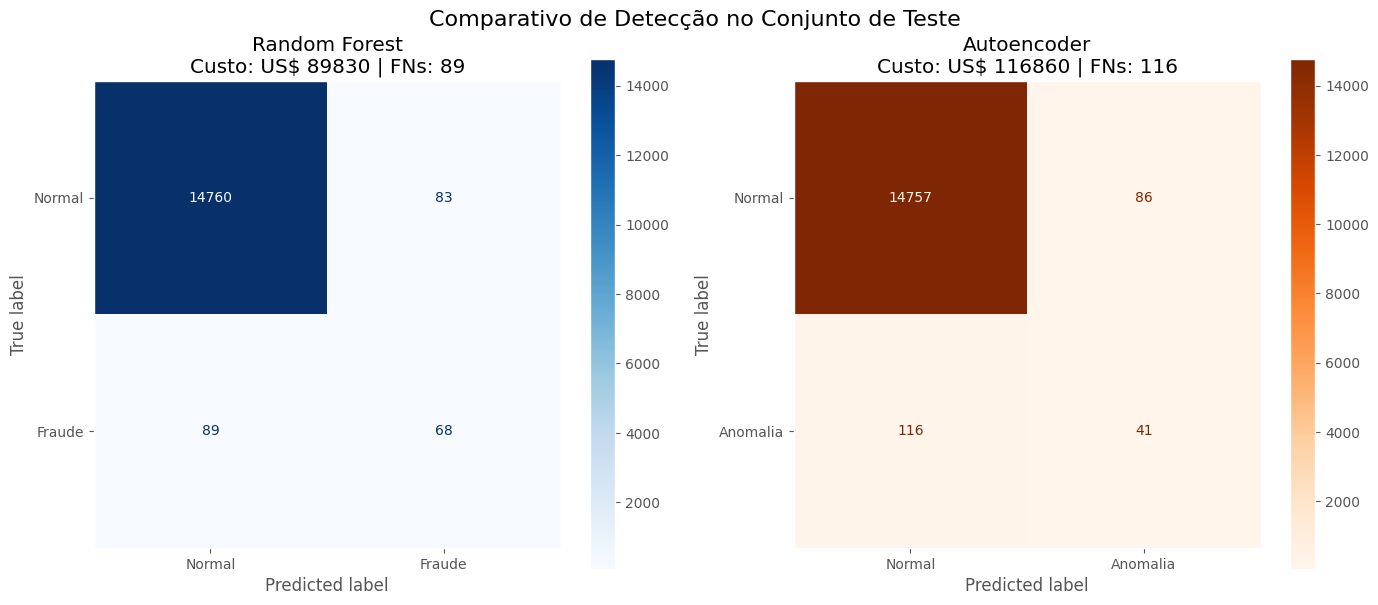

In [11]:
# Célula 9

from sklearn.metrics import ConfusionMatrixDisplay

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Matriz do Random Forest
cm_rf = confusion_matrix(y_test, y_test_pred_rf)
disp_rf = ConfusionMatrixDisplay(confusion_matrix=cm_rf, display_labels=['Normal', 'Fraude'])
disp_rf.plot(ax=axes[0], cmap='Blues', values_format='d')
axes[0].set_title(f'Random Forest\nCusto: US$ {cost_rf} | FNs: {fn_rf}')
axes[0].grid(False) # Remove as linhas de grade por cima da matriz

# Matriz do Autoencoder
cm_ae = confusion_matrix(y_test, y_test_pred_ae)
disp_ae = ConfusionMatrixDisplay(confusion_matrix=cm_ae, display_labels=['Normal', 'Anomalia'])
disp_ae.plot(ax=axes[1], cmap='Oranges', values_format='d')
axes[1].set_title(f'Autoencoder\nCusto: US$ {cost_ae} | FNs: {fn_ae}')
axes[1].grid(False)

plt.suptitle('Comparativo de Detecção no Conjunto de Teste', fontsize=16)
plt.tight_layout()
plt.show()

10: Explicabilidade (XAI) com SHAP


O Autoencoder funciona como uma "caixa preta" e é difícil explicar matematicamente o motivo exato pelo qual ele reconstruiu mal um dado. No entanto, o Random Forest pode ser explicado com precisão usando a Teoria dos Jogos através do SHAP (SHapley Additive exPlanations).

Isso responde à pergunta de negócios: "Por que a inteligência artificial bloqueou a transação do cliente X?"

O Random Forest é ótimo em acertar se uma transação é fraude ou não, mas ele não diz nativamente o porquê. É aqui que entra o SHAP (SHapley Additive exPlanations). O SHAP é uma biblioteca avançada de explicabilidade em Inteligência Artificial baseada na Teoria dos Jogos cooperativos. É extremamente pesado computacionalmente. Em produção/pesquisa local no Colab, pegamos uma amostra representativa do teste para gerar o gráfico sem travar a memória.



Gerando análise de explicabilidade (SHAP) para o Random Forest...


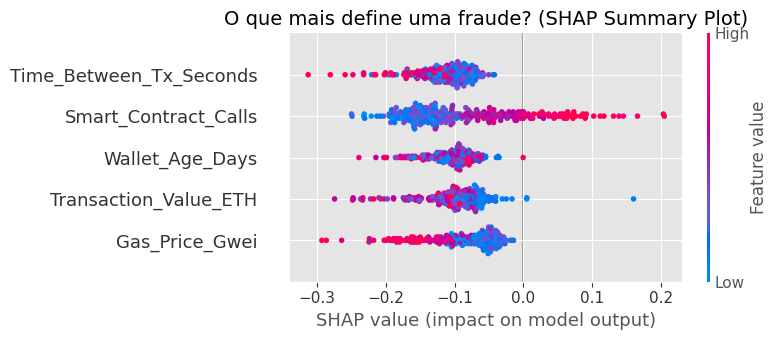

In [12]:
# Célula 10

import shap
import matplotlib.pyplot as plt

print("Gerando análise de explicabilidade (SHAP) para o Random Forest...")

# 1. Criar o explicador SHAP usando o modelo treinado
explainer = shap.TreeExplainer(rf_best_model)

# 2. Calcular os valores SHAP para os dados de Teste (pegamos uma amostra)
X_test_sample = X_test.sample(n=300, random_state=42)
shap_values = explainer.shap_values(X_test_sample)

# 3. Controle de Versão: Adaptando a extração da classe positiva (Fraude)
if isinstance(shap_values, list):
    # Versões antigas do SHAP: Retorna uma lista
    shap_values_positive_class = shap_values[1]
elif len(shap_values.shape) == 3:
    # Versões recentes do SHAP: Retorna array 3D (amostras, features, classes)
    shap_values_positive_class = shap_values[:, :, 1]
else:
    # Fallback de segurança
    shap_values_positive_class = shap_values

# 4. Plotar o Summary Plot
plt.figure(figsize=(10, 6))
plt.title("O que mais define uma fraude? (SHAP Summary Plot)", fontsize=14)
shap.summary_plot(shap_values_positive_class, X_test_sample, show=False)
plt.tight_layout()
plt.show()

Nota do Pesquisador: A integração da análise SHAP (Explicabilidade de IA) neste projeto garante conformidade com regulamentações modernas de proteção de dados (como LGPD e GDPR). Quando um cliente tem sua transação bloqueada, o modelo não atua como uma "caixa preta"; a empresa consegue justificar matematicamente quais variáveis (ex: idade da carteira, volume de tokens) acionaram o alerta de segurança.